In [3]:
# imports
import os
import numpy as np
import pandas as pd
import random
import datetime
import subprocess
import math
import pickle
from tqdm.notebook import tqdm
import anndata
import scanpy as sc
from datasets import load_from_disk

# visualization
import matplotlib.pyplot as plt

# ML
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, auc, confusion_matrix, log_loss
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.neural_network import MLPClassifier
from sklearn.utils import shuffle

# cpu cores
num_proc = 23

# training dataset size
subsample_size = 10_000

In [4]:
# load gene_ensembl_id:token dictionary
with open("genecorpus_30M/token_dictionary.pkl", "rb") as fp:
    token_dictionary = pickle.load(fp)
token_gene_dict = {v: k for k,v in token_dictionary.items()}

# prepare targets and labels
def prep_inputs(genegroup1, genegroup2, balance):

    targets1 = [gene for gene in genegroup1 if gene in token_dictionary]
    targets2 = [gene for gene in genegroup2 if gene in token_dictionary]
    
    if balance == "balance":
        min_sample = min(len(targets1), len(targets2))
        random.seed()
        targets1 = random.sample(targets1, min_sample)
        random.seed()
        targets2 = random.sample(targets2, min_sample)

    targets1_id = [token_dictionary[gene] for gene in targets1]
    targets2_id = [token_dictionary[gene] for gene in targets2]
    
    targets = np.array(targets1_id + targets2_id)
    labels = np.array([0]*len(targets1_id) + [1]*len(targets2_id))
    nsplits = min(5, min(len(targets1_id), len(targets2_id))-1)
    assert nsplits > 2
    print(f"# targets1: {len(targets1_id)}\n# targets2: {len(targets2_id)}\n# splits: {nsplits}")
    return targets, labels, nsplits

### CHANGED CODE ###
# dosage_sens_tfs is a pickle, not csv. 
# also needed to convert lists to pandas Series objects to dropna().
dosage_tfs_pickle = pd.read_pickle("genecorpus_30M/example_input_files/gene_classification/dosage_sensitive_tfs/dosage_sensitivity_TFs.pickle")
sensitive = pd.Series(dosage_tfs_pickle["Dosage-sensitive TFs"]).dropna()
insensitive = pd.Series(dosage_tfs_pickle["Dosage-insensitive TFs"]).dropna()
targets, labels, nsplits = prep_inputs(sensitive, insensitive, "balance")

# load training dataset
train_dataset=load_from_disk("genecorpus_30M/genecorpus_30_2048.dataset")
shuffled_train_dataset = train_dataset.shuffle()

# reduce training dataset to 5x subsample size (to leave room for further filtering for cells that express target genes)
subsampled_training_dataset = shuffled_train_dataset.select([i for i in range(subsample_size*5)])

def if_contains_target(example):
    a = targets
    b = example['input_ids']
    return not set(a).isdisjoint(b)

# filter dataset for cells that express target genes
data_w_target = subsampled_training_dataset.filter(if_contains_target, num_proc=num_proc)

# subsample data to desired number of training examples
data_subsample = data_w_target.select([i for i in range(subsample_size)])

def get_ranks(example):
    example_rank_dict = dict(zip(example["input_ids"],[2048-i for i in range(example["length"])]))
    target_vector = [example_rank_dict.get(target,0) for target in targets]
    example["target_vector"] = target_vector
    return example

# get ranks of target genes within training cells for rank-based trials
data_w_target_vectors = data_subsample.map(get_ranks, num_proc=num_proc)
target_arr = np.transpose(np.array(data_w_target_vectors["target_vector"]))

# targets1: 122
# targets2: 122
# splits: 5


Filter (num_proc=23):   0%|          | 0/50000 [00:00<?, ? examples/s]

Map (num_proc=23):   0%|          | 0/10000 [00:00<?, ? examples/s]

In [ ]:
# functions to evaluate classifier
def classifier_predict(model_type, model, eval_arr, labels_eval, mean_fpr):
    y_pred = model.predict(eval_arr)
    y_true = labels_eval
    conf_mat = confusion_matrix(y_true, y_pred)
    # probability of class 1
    if model_type == "SVM":
        y_prob = model.decision_function(eval_arr)
        fpr, tpr, _ = roc_curve(y_true, y_prob)
    else:
        y_prob = model.predict_proba(eval_arr)
        fpr, tpr, _ = roc_curve(y_true, y_prob[:,1])
    # plot roc_curve for this split
    plt.plot(fpr, tpr)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC')
    plt.show()
    # interpolate to graph
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    return fpr, tpr, interp_tpr, conf_mat 

# get cross-validated AUC mean and sd metrics
def get_cross_valid_metrics(all_tpr, all_roc_auc, all_tpr_wt):
    wts = [count/sum(all_tpr_wt) for count in all_tpr_wt]
    print(wts)
    all_weighted_tpr = [a*b for a,b in zip(all_tpr, wts)]
    mean_tpr = np.sum(all_weighted_tpr, axis=0)
    mean_tpr[-1] = 1.0
    all_weighted_roc_auc = [a*b for a,b in zip(all_roc_auc, wts)]
    roc_auc = np.sum(all_weighted_roc_auc)
    roc_auc_sd = math.sqrt(np.average((all_roc_auc-roc_auc)**2, weights=wts))
    return mean_tpr, roc_auc, roc_auc_sd

def binary_cross_entropy(y_true, y_pred):
    epsilon = 1e-9
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# cross-validate token classifier
def cross_validate(model_type, model, target_arr, labels, nsplits, subsample_size, num_proc):
    print(f"# training cells: {target_arr.shape[1]}")
    
    # initiate eval metrics to return
    num_classes = len(set(labels))
    mean_fpr = np.linspace(0, 1, 100)
    all_tpr = []
    all_roc_auc = []
    all_tpr_wt = []
    confusion = np.zeros((num_classes,num_classes))
    
    # set up cross-validation splits
    skf = StratifiedKFold(n_splits=nsplits, shuffle=True)
    
    # train and evaluate
    iteration_num = 0
    
    train_loss = []
    test_loss = []
    
    for train_index, eval_index in tqdm(skf.split(target_arr, labels)):

        print(f"****** Crossval split: {iteration_num}/{nsplits-1} ******\n")
        # generate cross-validation splits
        targets_train, targets_eval = target_arr[train_index], target_arr[eval_index]
        labels_train, labels_eval = labels[train_index], labels[eval_index]
        
        model = model
        # train_loss = []
        # test_loss = []
        
        if model_type == "MLP":
            for epoch in range(model.max_iter):
                model.fit(targets_train, labels_train)
                train_loss.append(model.loss_curve_[-1])
                y_test_pred = model.predict_proba(targets_eval)[:, 1]
                test_loss.append(binary_cross_entropy(labels_eval, y_test_pred))
        else:
             # train the token classifier
            model.fit(targets_train, labels_train)
            
        # all_train_loss.append(train_loss)
        # all_test_loss.append(test_loss)

        # evaluate model
        fpr, tpr, interp_tpr, conf_mat = classifier_predict(model_type, model, targets_eval, labels_eval, mean_fpr)

        # append to tpr and roc lists
        confusion = confusion + conf_mat
        all_tpr.append(interp_tpr)
        all_roc_auc.append(auc(fpr, tpr))
        # append number of eval examples by which to weight tpr in averaged graphs
        all_tpr_wt.append(len(tpr))
        
        iteration_num = iteration_num + 1
    
    # get overall metrics for cross-validation
    mean_tpr, roc_auc, roc_auc_sd = get_cross_valid_metrics(all_tpr, all_roc_auc, all_tpr_wt)
    
    # mean_train_loss = np.mean(all_train_loss, axis=0)
    # mean_test_loss = np.mean(all_test_loss, axis=0)
    
    if model_type == "MLP":
        return all_roc_auc, roc_auc, roc_auc_sd, mean_fpr, mean_tpr, confusion, test_loss, train_loss
    else:
        return all_roc_auc, roc_auc, roc_auc_sd, mean_fpr, mean_tpr, confusion

def plot_ROC(bundled_data, title):
    fig = plt.figure()
    fig.set_size_inches(17, 10.5)
    plt.rcParams.update({'font.size': 20})
    lw = 4
    for roc_auc, roc_auc_sd, mean_fpr, mean_tpr, sample, color, linestyle in bundled_data:
        plt.plot(mean_fpr, mean_tpr, color=color,
                 lw=lw, label="{0} (AUC {1:0.2f} $\pm$ {2:0.2f})".format(sample, roc_auc, roc_auc_sd), linestyle=linestyle)
    plt.plot([0, 1], [0, 1], color='black', lw=lw, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc="lower right")

    plt.show()

In [ ]:
model = RandomForestClassifier(max_depth=2)
all_roc_auc0, roc_auc0, roc_auc_sd0, mean_fpr0, mean_tpr0, confusion0 \
    = cross_validate("RF", model, target_arr, labels, nsplits, subsample_size, 1)

model = LogisticRegression()
all_roc_auc1, roc_auc1, roc_auc_sd1, mean_fpr1, mean_tpr1, confusion1 \
    = cross_validate("LR", model, target_arr, labels, nsplits, subsample_size, 1)

model = SVC()
all_roc_auc2, roc_auc2, roc_auc_sd2, mean_fpr2, mean_tpr2, confusion2 \
    = cross_validate("SVM", model, target_arr, labels, nsplits, subsample_size, 1)

# training cells: 10000


0it [00:00, ?it/s]

****** Crossval split: 0/4 ******



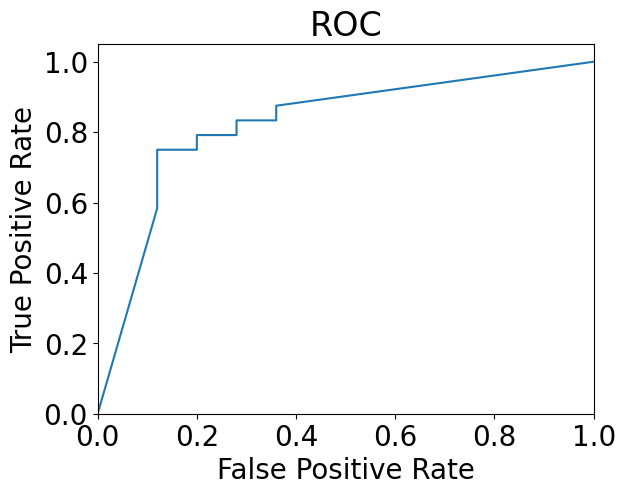

****** Crossval split: 1/4 ******



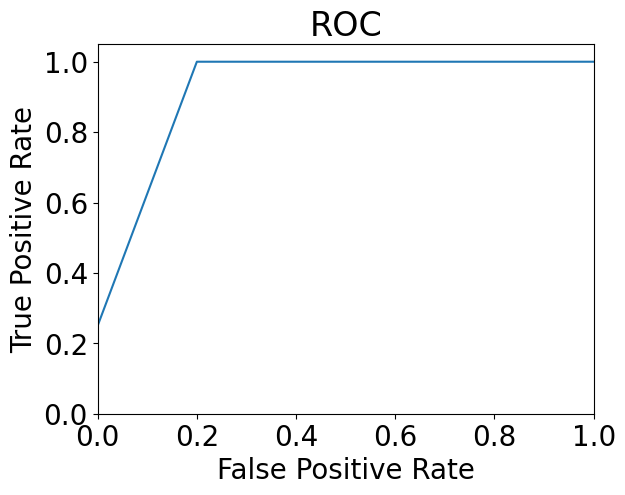

****** Crossval split: 2/4 ******



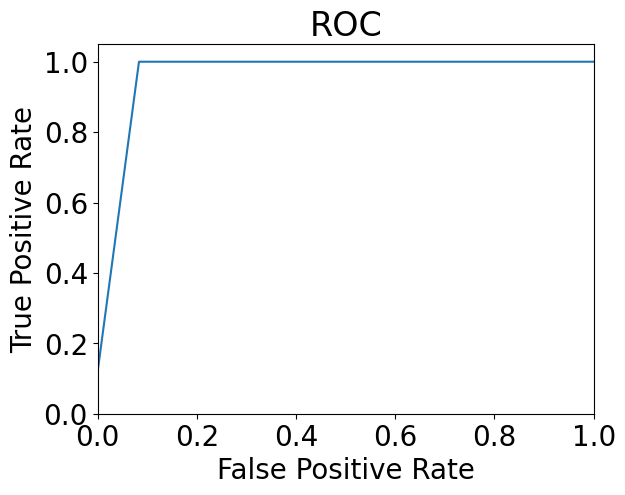

****** Crossval split: 3/4 ******



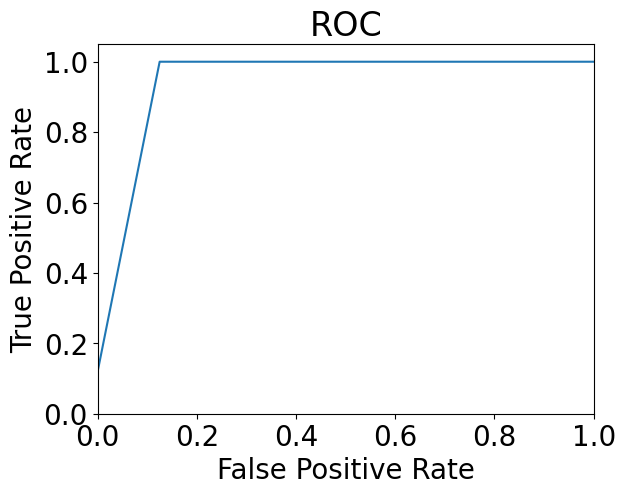

****** Crossval split: 4/4 ******



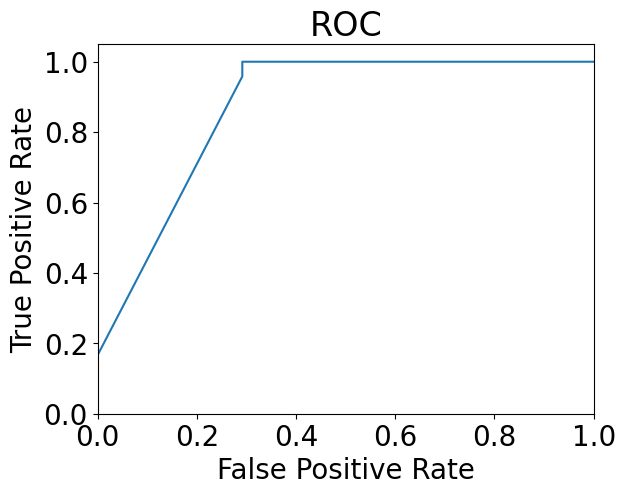

[0.2857142857142857, 0.17142857142857143, 0.17142857142857143, 0.17142857142857143, 0.2]


In [ ]:
# https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html
    # ^ use built-in MLP neural network, update parameters though?

target_arr, labels = shuffle(target_arr, labels) # random_state = 42 to test
model = MLPClassifier(hidden_layer_sizes=(64, ), 
                      activation = 'relu',
                      solver='sgd', 
                      alpha=0.01, 
                      learning_rate_init=0.001,
                      learning_rate='adaptive',
                      max_iter=100,
                      early_stopping=False,
                      warm_start=True,
                      shuffle=True)
all_roc_auc3, roc_auc3, roc_auc_sd3, mean_fpr3, mean_tpr3, confusion3, test_loss3, train_loss3 \
    = cross_validate("MLP", model, target_arr, labels, nsplits, subsample_size, 1)    

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(train_loss3) + 1), train_loss3, label="train loss", color="blue")
plt.plot(range(1, len(test_loss3) + 1), test_loss3, label="test loss", color="red")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.title("loss over epochs")
plt.legend()
plt.grid()
plt.xlim(1, 100)
plt.savefig("data/MLPloss.png")
plt.close()

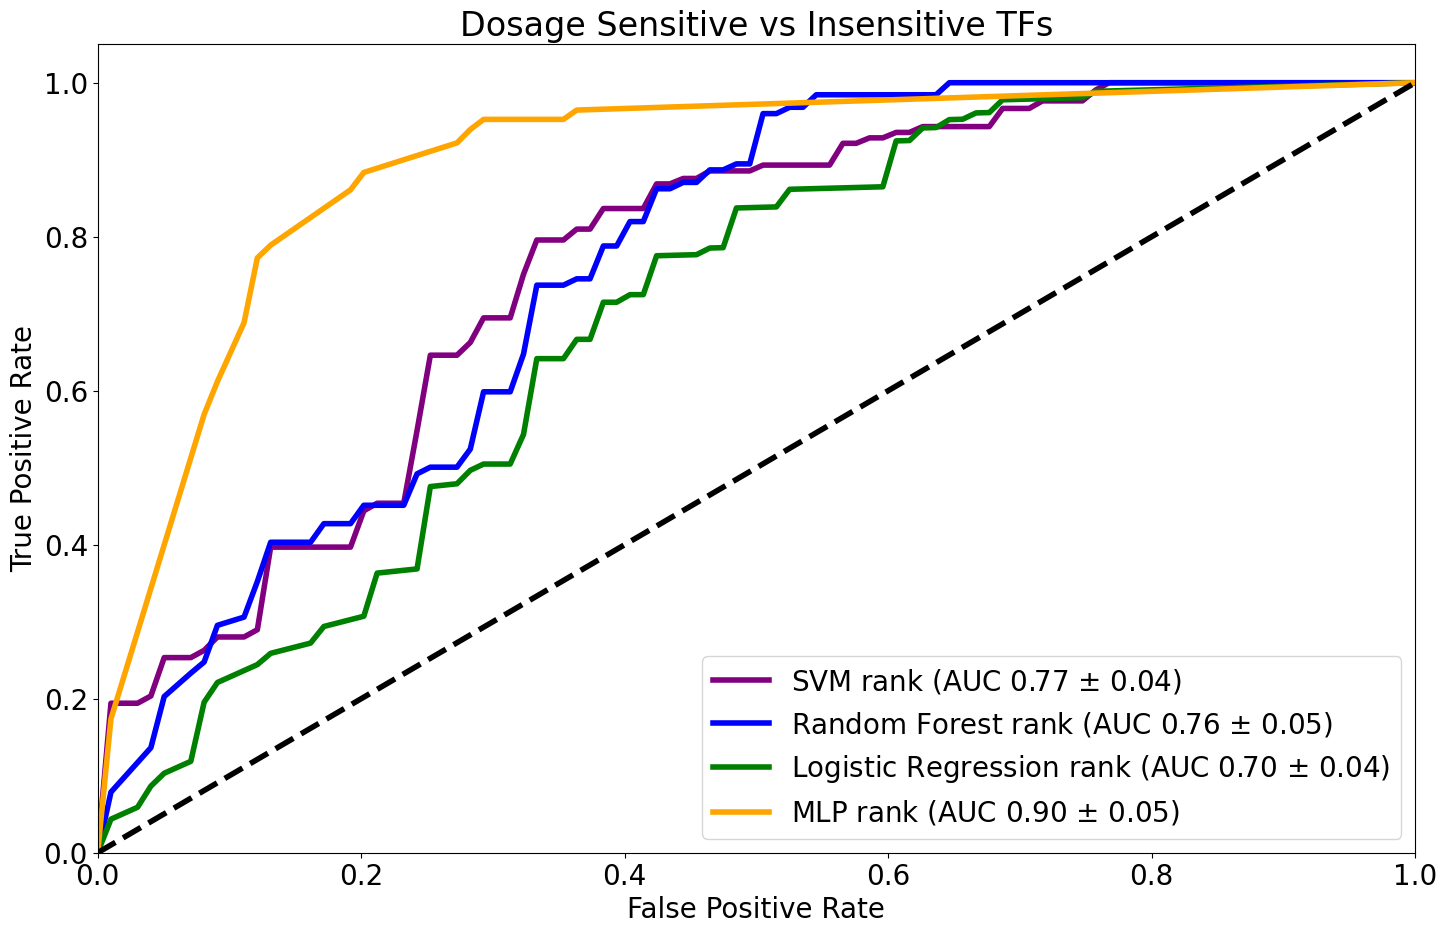

<Figure size 640x480 with 0 Axes>

In [26]:
# bundle data for plotting
bundled_data = []
bundled_data += [(roc_auc2, roc_auc_sd2, mean_fpr2, mean_tpr2, "SVM rank", "purple", "solid")]
bundled_data += [(roc_auc0, roc_auc_sd0, mean_fpr0, mean_tpr0, "Random Forest rank", "blue", "solid")]
bundled_data += [(roc_auc1, roc_auc_sd1, mean_fpr1, mean_tpr1, "Logistic Regression rank", "green", "solid")]
bundled_data += [(roc_auc3, roc_auc_sd3, mean_fpr3, mean_tpr3, "MLP rank", "orange", "solid")]

# plot ROC
plot_ROC(bundled_data, 'Dosage Sensitive vs Insensitive TFs')
plt.savefig('data/roc_plot.png')

In [ ]:
# from sklearn.utils import shuffle

# target_arr, labels = shuffle(target_arr, labels, random_state=42)

# skf = StratifiedKFold(n_splits=nsplits, shuffle=True)

# iteration_num = 0

# for train_index, eval_index in tqdm(skf.split(target_arr, labels)):

#     print(f"****** Crossval split: {iteration_num}/{nsplits-1} ******\n")
#     # generate cross-validation splits
#     targets_train, targets_eval = target_arr[train_index], target_arr[eval_index]
#     labels_train, labels_eval = labels[train_index], labels[eval_index]
    
#     for epoch in range(model.max_iter):
#         model.fit(targets_train, labels_train)

#     print(model.predict_proba(targets_train)[:10])
#     print('********************************')
    
#     iteration_num = iteration_num + 1


0it [00:00, ?it/s]

****** Crossval split: 0/4 ******



AttributeError: This 'SVC' has no attribute 'predict_proba'